<table style="width: 100%; border-collapse: collapse; border: none; background: #eef2ff; border-left: 6px solid #4f46e5; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        El Test de Turing: ¿Puede Pensar una Máquina? 🕵️💬
      </h1>
      <p style="margin: 6px 0 0 0; color: #4f46e5; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Introducción a la Inteligencia Artificial
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #4f46e5; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 00 • Fundamentos de IA
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #4f46e5; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Introduccion%20a%20la%20Inteligencia%20Artificial/00%20-%20Fundamentos%20y%20Origenes%20de%20la%20IA/02_El_Test_de_Turing.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## 🎯 ¿Qué vamos a aprender en este cuaderno?

Cerramos el **Módulo 00** con el experimento mental más influyente en la historia de la IA. Al finalizar este cuaderno podrás responder:

1. ¿En qué consiste el "juego de la imitación" propuesto por Alan Turing en 1950?
2. ¿Cómo se implementaría, en términos muy simples, un sistema capaz de participar en ese juego?
3. ¿Qué objeta el experimento mental de la **Habitación China** de John Searle?
4. ¿Por qué el Test de Turing sigue siendo relevante hoy, y cuáles son sus límites como medida de inteligencia?

---
## 1.5 El Test de Turing 🕵️

### El "Juego de la Imitación" (Alan Turing, 1950)

En 1950, el matemático británico **Alan Turing** publicó el artículo *"Computing Machinery and Intelligence"*, donde propuso reemplazar la pregunta filosóficamente escurridiza *"¿pueden pensar las máquinas?"* por una pregunta operacional y medible, a la que llamó el **juego de la imitación**:

* Un **interrogador humano (C)** se comunica por escrito (para evitar pistas de voz o apariencia) con otros dos participantes en habitaciones separadas: un **humano (A)** y una **máquina (B)**.
* El interrogador no sabe cuál es cuál, y su tarea es hacer preguntas de cualquier tipo para intentar **distinguir** al humano de la máquina.
* Si la máquina logra que el interrogador se equivoque con una frecuencia similar a cuando A y B son dos humanos, se dice que la máquina **pasó el test**.

> 💡 Turing reformuló una pregunta metafísica ("¿piensa la máquina?") en una pregunta **conductual y verificable**: ¿puede la máquina *comportarse* de forma indistinguible de un humano en una conversación de texto?

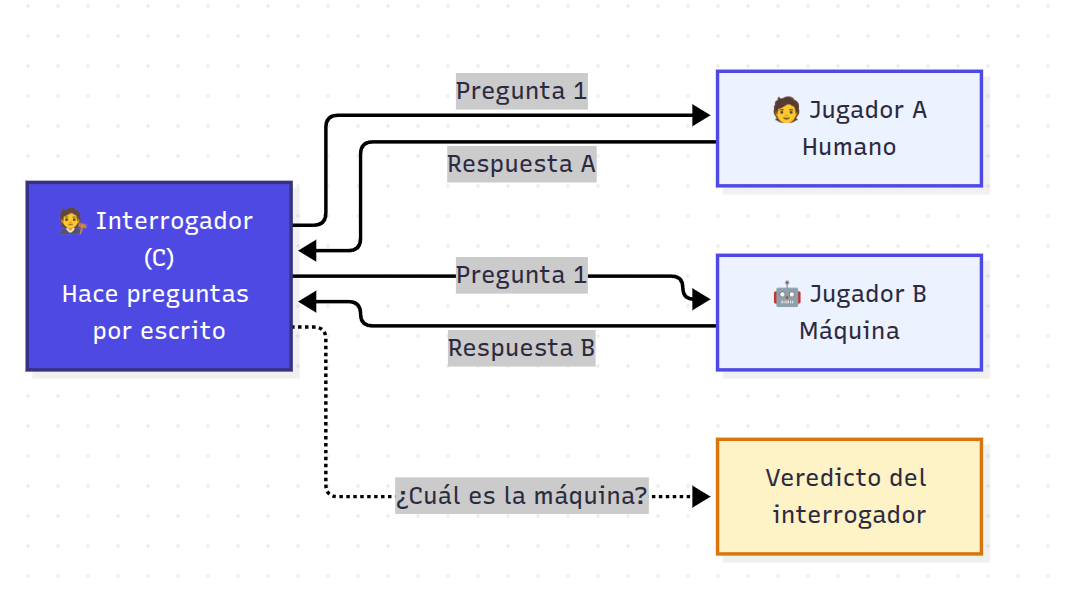

---
### ¿Cómo funciona el test en la práctica?

* El canal de comunicación es **estrictamente textual**: se busca evaluar únicamente la capacidad lingüística y de razonamiento, no la apariencia física ni la voz.
* No existe un umbral "oficial" único, pero eventos como el **Premio Loebner** han usado criterios como que al menos el 30% de los interrogadores confundan a la máquina con un humano tras una conversación breve.
* Es un test **puramente conductual**: no intenta verificar *cómo* razona internamente el sistema, solo *si su comportamiento observable* es indistinguible del de un humano.

Vamos a construir, con lógica condicional pura de Python (sin ninguna API externa ni modelo de lenguaje real), un chatbot de reglas muy simple al estilo de los primeros programas conversacionales — para ilustrar de forma concreta cómo sería participar del lado de la máquina (Jugador B) en este juego.

In [ ]:
import random

class ChatbotReglas:
    """Chatbot de juguete basado en reglas simples (en el espíritu de ELIZA, 1966).
    No comprende el lenguaje: únicamente empareja palabras clave del mensaje recibido
    con respuestas predefinidas. Sirve para ilustrar el rol de la máquina (Jugador B)
    en el Juego de la Imitación de Turing, sin usar ninguna API externa.
    """

    def __init__(self):
        self.reglas = [
            (["hola", "buenas", "saludos"],
             ["¡Hola! ¿Cómo te sientes hoy?", "Buenas, cuéntame qué tienes en mente."]),
            (["triste", "mal", "deprimid"],
             ["Lamento escuchar eso. ¿Qué crees que lo está causando?"]),
            (["feliz", "bien", "content"],
             ["Me alegra saberlo. ¿Qué te tiene tan contento?"]),
            (["nombre"],
             ["Mi nombre no es lo importante ahora mismo; hablemos de ti."]),
            (["clima", "tiempo"],
             ["No tengo forma de mirar por la ventana, pero ¿te gusta el clima de hoy?"]),
            (["por qué", "porque"],
             ["¿Por qué crees tú tú mismo que es así?"]),
        ]
        self.respuestas_default = [
            "Cuéntame más sobre eso.",
            "Interesante... ¿por qué dices eso?",
            "No estoy segura de entender del todo, ¿puedes explicarlo de otra forma?",
        ]

    def responder(self, mensaje: str) -> str:
        mensaje = mensaje.lower()
        for palabras_clave, respuestas in self.reglas:
            if any(palabra in mensaje for palabra in palabras_clave):
                return random.choice(respuestas)
        return random.choice(self.respuestas_default)


random.seed(42)
bot = ChatbotReglas()

preguntas_interrogador = [
    "Hola, ¿cómo estás?",
    "Hoy me siento un poco triste.",
    "¿Cuál es tu nombre?",
    "¿Por qué el cielo es azul?",
]

print("🕵️ Simulación del Juego de la Imitación (interrogatorio de texto)\n")
for pregunta in preguntas_interrogador:
    respuesta = bot.responder(pregunta)
    print(f"Interrogador: {pregunta}")
    print(f"Jugador B (máquina): {respuesta}\n")

### 🤔 ¿Este chatbot "pasaría" el Test de Turing?

En una conversación muy breve y casual, quizás logre no levantar sospechas. Pero el chatbot **no entiende absolutamente nada** de lo que se le dice: solo busca coincidencias de texto contra una lista fija de reglas. Vamos a exponer esta limitación interrogándolo con una pregunta fuera de su base de reglas.

In [ ]:
# Interrogamos al chatbot con una pregunta factual y de razonamiento fuera de sus reglas,
# para evidenciar que "responder" no es lo mismo que "comprender".

pregunta_dificil = "¿Cuánto es 347 multiplicado por 289, y por qué el resultado es un número impar?"
respuesta = bot.responder(pregunta_dificil)

print(f"Interrogador: {pregunta_dificil}")
print(f"Jugador B (máquina): {respuesta}")
print("\n⚠️ El chatbot no realizó ningún cálculo ni razonamiento: simplemente no encontró ")
print("   palabras clave en sus reglas y devolvió una respuesta genérica de relleno.")

---
### La Crítica de John Searle: la Habitación China (1980) 🈳🚪

Incluso si una máquina lograra superar el Test de Turing de forma convincente, el filósofo **John Searle** argumentó en 1980 que esto **no demostraría que la máquina "entiende" o "piensa"**. Su experimento mental es el siguiente:

> Imagina a una persona que no habla ni entiende chino, encerrada en una habitación. Recibe mensajes escritos en caracteres chinos por una ranura. Dentro tiene un **manual de reglas en su idioma nativo** que le indica, para cada combinación de símbolos de entrada, qué símbolos chinos debe devolver como salida. Siguiendo el manual mecánicamente, la persona logra producir respuestas en chino perfectamente coherentes — sin comprender ni una sola palabra del idioma.

Para un interrogador externo, la habitación "parece" entender chino. Pero, según Searle, adentro solo hay **manipulación de símbolos sintácticos (forma)**, sin ninguna **comprensión semántica (significado)**. Este argumento distingue entre:

* **IA Débil:** las máquinas pueden *simular* el pensamiento de forma útil, sin que eso implique que realmente piensan.
* **IA Fuerte:** una máquina que ejecuta el programa correcto *literalmente* posee una mente y estados mentales genuinos.

Searle usó la Habitación China precisamente para argumentar en contra de la posición de la IA Fuerte.

### ⚖️ Comparación: Test de Turing vs. Habitación China

| Aspecto | Test de Turing (Turing, 1950) | Habitación China (Searle, 1980) |
|---|---|---|
| **Qué evalúa** | Comportamiento observable (¿engaña al interrogador?) | Si el comportamiento correcto implica comprensión real |
| **Postura implícita** | El comportamiento indistinguible es suficiente para hablar de "inteligencia" | El comportamiento correcto no basta: falta significado (semántica) |
| **Relación con nuestro chatbot** | El bot de reglas podría "pasar" fragmentos cortos del test | El bot es, literalmente, un manual de reglas sintácticas — la Habitación China en miniatura |
| **Posición filosófica asociada** | Funcionalismo / conductismo computacional | Crítica a la IA Fuerte; defensa del rol de la semántica y la biología |

---
### Relevancia y límites actuales del Test de Turing 🔍

Con la llegada de los LLMs modernos, muchas personas reportan conversaciones con IA que serían indistinguibles de un humano en intercambios cortos — algo que Turing habría considerado un logro notable. Sin embargo, la comunidad de IA reconoce varias limitaciones del test como **medida general de inteligencia**:

* **Mide engaño, no inteligencia:** un sistema puede volverse muy bueno "pareciendo humano" (incluyendo errores tipográficos deliberados) sin que eso implique razonamiento general o comprensión profunda.
* **Es binario y dependiente del interrogador:** el resultado depende de la habilidad e ingenio de quien pregunta, no de una métrica objetiva y reproducible.
* **No evalúa tareas del mundo real:** no dice nada sobre percepción visual, manipulación física, planeación a largo plazo o fiabilidad factual.
* **Alternativas modernas:** benchmarks como el *Winograd Schema Challenge* (razonamiento de sentido común sobre pronombres ambiguos) o evaluaciones multitarea a gran escala intentan medir capacidades más específicas y difíciles de "actuar".

> 🎯 El Test de Turing sigue siendo valioso como **punto de partida histórico y filosófico**, pero hoy se complementa —no se reemplaza— con baterías de evaluación mucho más específicas y cuantitativas.

---
## ✍️ Ejercicio práctico guiado

**Tu misión:** agrega una nueva regla a `bot.reglas` para que el chatbot pueda responder de forma más convincente a mensajes sobre **mascotas** (por ejemplo, si el mensaje contiene la palabra "perro" o "gato").

In [ ]:
### TU CÓDIGO AQUÍ ###
# Agrega una tupla (lista_de_palabras_clave, lista_de_respuestas) a bot.reglas

nueva_regla = None  # Pista: (["perro", "gato", "mascota"], ["Cuéntame más sobre tu mascota."])

if nueva_regla:
    bot.reglas.append(nueva_regla)
    print("Regla agregada. Probemos con un mensaje nuevo:")
    mensaje_prueba = "Tengo un perro llamado Toby."
    print(f"Interrogador: {mensaje_prueba}")
    print(f"Jugador B (máquina): {bot.responder(mensaje_prueba)}")
else:
    print("Todavía no definiste tu nueva regla. Reemplaza 'None' por una tupla válida.")

---
<details>
<summary>💡 Ver un ejemplo de solución</summary>

```python
nueva_regla = (["perro", "gato", "mascota"], ["Cuéntame más sobre tu mascota.", "¿Hace cuánto la tienes?"])
bot.reglas.append(nueva_regla)

mensaje_prueba = "Tengo un perro llamado Toby."
print(f"Interrogador: {mensaje_prueba}")
print(f"Jugador B (máquina): {bot.responder(mensaje_prueba)}")
```

Este ejercicio ilustra, en miniatura, cómo los primeros chatbots "mejoraban" agregando más y más reglas manuales — un enfoque que escala mal y es exactamente lo que critica el argumento de la Habitación China: sin importar cuántas reglas agregues, el sistema sigue sin **comprender** lo que dice.

</details>

---
## 📌 Resumen / Puntos Clave

* El **Test de Turing (1950)** reformula "¿pueden pensar las máquinas?" en una pregunta conductual: ¿puede una máquina conversar de forma indistinguible de un humano?
* El test se basa en un **juego de imitación** con un interrogador humano y comunicación puramente textual.
* La **Habitación China (Searle, 1980)** argumenta que superar el test no implica comprensión real: puede haber manipulación sintáctica perfecta sin semántica alguna.
* Nuestro chatbot de reglas ilustra ambas ideas: puede "engañar" en preguntas simples (Turing), pero solo manipula símbolos sin entender nada (Habitación China).
* El Test de Turing sigue siendo relevante históricamente, pero hoy se complementa con benchmarks más específicos, porque mide **engaño conductual**, no inteligencia general.
* Con este cuaderno cerramos el **Módulo 00: Fundamentos y Orígenes de la IA**. El siguiente paso del curso profundiza en las técnicas concretas de razonamiento y aprendizaje automático.

### 🧠 Autoevaluación

1. Explica con tus propias palabras la diferencia entre "comportarse de forma inteligente" (Turing) y "comprender" (crítica de Searle).
2. ¿Por qué el chatbot de reglas de este cuaderno es un buen ejemplo, en miniatura, del argumento de la Habitación China?
3. Menciona dos limitaciones del Test de Turing como medida general de inteligencia, y propone qué tipo de evaluación complementaria usarías para superarlas.
4. Si un LLM moderno lograra engañar consistentemente a interrogadores expertos durante horas de conversación, ¿consideras que eso zanjaría el debate sobre si "piensa" o no? Argumenta tu posición.

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Asignatura: Introducción a la Inteligencia Artificial</i>
  </p>
</div>